> ⚠️ **Before Running:** Update the dataset path below to point to your Google Drive folder.
> Dataset: [Download Here](https://drive.google.com/drive/folders/14dp4kEdV9k6esJs0tGTNb3AKFF6d-s9I?usp=sharing)
> Place it in your Google Drive under: `MyDrive/GAN_ART_IMAGES/Images/`

In [4]:
# Step 1: Repo clone (already done, but safe to skip if folder exists)
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 28.10 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix


In [6]:
# Alternative Manual Installation (if Conda fails)
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install dominate visdom

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=eecb81f365005d0455b47e715139c3c4a6d6abaf1e31698c0af1f4328c293692
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [7]:
# Step 3: Download pretrained painting models (true GAN adversarial)
!bash ./scripts/download_cyclegan_model.sh style_monet
!bash ./scripts/download_cyclegan_model.sh style_vangogh
!bash ./scripts/download_cyclegan_model.sh style_cezanne
!bash ./scripts/download_cyclegan_model.sh style_ukiyoe

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2025-12-28 07:08:54--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  27.6MB/s    in 1.6s    

2025-12-28 07:08:56 (27.6 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Note: 

In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Step 4: Run inference on your 8000+ images folder
!python test.py --dataroot /content/drive/MyDrive/GAN_ART_IMAGES/Images \
                --name style_monet_pretrained \
                --model test \
                --no_dropout \
                --preprocess none \
                --load_size 256 \
                --crop_size 256 \
                --num_test 10000

Mounted at /content/drive
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/GAN_ART_IMAGES/Images	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
   

In [13]:
!ls ./results/style_monet_pretrained/test_latest/images/ | wc -l   # Kitni files bani hain dekho
!ls ./results/style_monet_pretrained/test_latest/images/ | head -20  # Pehli 20 files ke naam dekho

5508
1000268201_693b08cb0e_fake.png
1000268201_693b08cb0e_real.png
1001773457_577c3a7d70_fake.png
1001773457_577c3a7d70_real.png
1002674143_1b742ab4b8_fake.png
1002674143_1b742ab4b8_real.png
1003163366_44323f5815_fake.png
1003163366_44323f5815_real.png
1007129816_e794419615_fake.png
1007129816_e794419615_real.png
1007320043_627395c3d8_fake.png
1007320043_627395c3d8_real.png
1009434119_febe49276a_fake.png
1009434119_febe49276a_real.png
1012212859_01547e3f17_fake.png
1012212859_01547e3f17_real.png
1015118661_980735411b_fake.png
1015118661_980735411b_real.png
1015584366_dfcec3c85a_fake.png
1015584366_dfcec3c85a_real.png


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import os

result_dir = "./results/style_monet_pretrained/test_latest/images/"
fake_b_files = [f for f in os.listdir(result_dir) if f.startswith("fake_B")]

plt.figure(figsize=(20, 10))
for i in range(min(10, len(fake_b_files))):  # Pehle 10 results dikhao
    img_path = os.path.join(result_dir, fake_b_files[i])
    img = Image.open(img_path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Monet Style {i+1}")
    plt.axis('off')
plt.suptitle("True CycleGAN Monet Painting Results", fontsize=20)
plt.show()

<Figure size 2000x1000 with 0 Axes>

In [17]:
!ls -l ./results/style_monet_pretrained/test_latest/images/ | head -20

total 1833508
-rw-r--r-- 1 root root 389816 Dec 28 07:13 1000268201_693b08cb0e_fake.png
-rw-r--r-- 1 root root 420096 Dec 28 07:13 1000268201_693b08cb0e_real.png
-rw-r--r-- 1 root root 389238 Dec 28 07:13 1001773457_577c3a7d70_fake.png
-rw-r--r-- 1 root root 424077 Dec 28 07:13 1001773457_577c3a7d70_real.png
-rw-r--r-- 1 root root 380593 Dec 28 07:13 1002674143_1b742ab4b8_fake.png
-rw-r--r-- 1 root root 330277 Dec 28 07:13 1002674143_1b742ab4b8_real.png
-rw-r--r-- 1 root root 386897 Dec 28 07:13 1003163366_44323f5815_fake.png
-rw-r--r-- 1 root root 391928 Dec 28 07:13 1003163366_44323f5815_real.png
-rw-r--r-- 1 root root 388977 Dec 28 07:13 1007129816_e794419615_fake.png
-rw-r--r-- 1 root root 339786 Dec 28 07:13 1007129816_e794419615_real.png
-rw-r--r-- 1 root root 363809 Dec 28 07:13 1007320043_627395c3d8_fake.png
-rw-r--r-- 1 root root 368852 Dec 28 07:13 1007320043_627395c3d8_real.png
-rw-r--r-- 1 root root 371560 Dec 28 07:14 1009434119_febe49276a_fake.png
-rw-r--r-- 1 root root 3

In [18]:
!ls -la

total 120
drwxr-xr-x 13 root root  4096 Dec 28 07:13 .
drwxr-xr-x 12 root root  4096 Dec 28 07:06 ..
drwxr-xr-x  6 root root  4096 Dec 28 07:09 checkpoints
-rw-r--r--  1 root root  8001 Dec 28 07:06 CycleGAN.ipynb
drwxr-xr-x  3 root root  4096 Dec 28 07:09 data
drwxr-xr-x  3 root root  4096 Dec 28 07:06 datasets
drwxr-xr-x  2 root root  4096 Dec 28 07:06 docs
-rw-r--r--  1 root root   284 Dec 28 07:06 environment.yml
drwxr-xr-x  8 root root  4096 Dec 28 07:06 .git
-rw-r--r--  1 root root   768 Dec 28 07:06 .gitignore
drwxr-xr-x  2 root root  4096 Dec 28 07:06 imgs
-rw-r--r--  1 root root  3565 Dec 28 07:06 LICENSE
drwxr-xr-x  3 root root  4096 Dec 28 07:09 models
drwxr-xr-x  3 root root  4096 Dec 28 07:09 options
-rw-r--r--  1 root root  7122 Dec 28 07:06 pix2pix.ipynb
-rw-r--r--  1 root root 16743 Dec 28 07:06 README.md
-rw-r--r--  1 root root   795 Dec 28 07:06 .replit
drwxr-xr-x  3 root root  4096 Dec 28 07:13 results
drwxr-xr-x  4 root root  4096 Dec 28 07:06 scripts
-rw-r--r--  1 

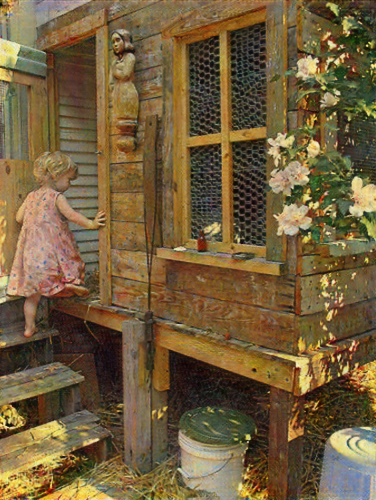

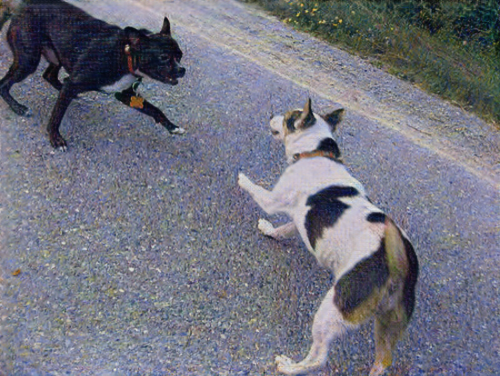

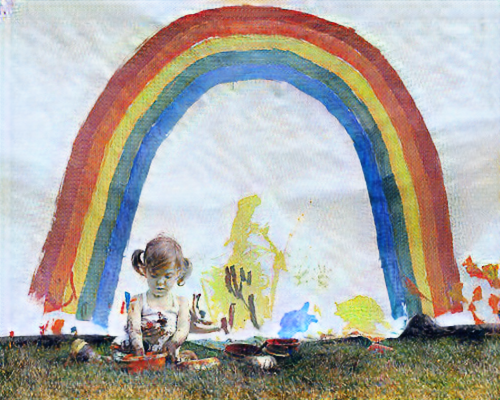

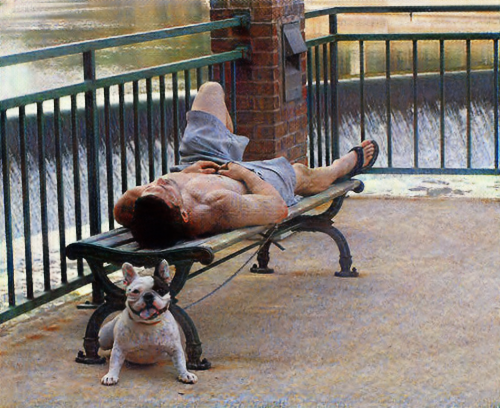

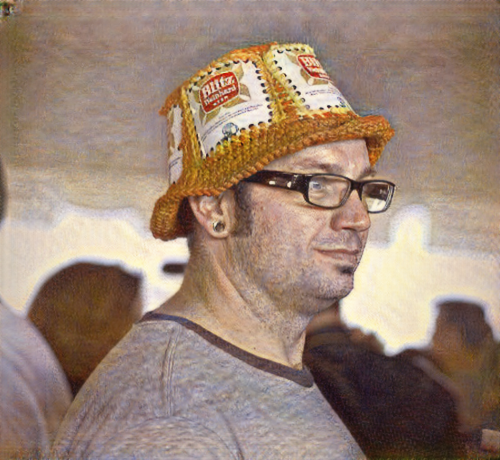

In [22]:
from IPython.display import Image, display
import os
results_dir = './results/style_monet_pretrained/test_latest/images/'
fake_images = sorted([f for f in os.listdir(results_dir) if f.endswith('_fake.png')])
for img in fake_images[:5]:  # Show first 5 styled results
    display(Image(os.path.join(results_dir, img)))